In [1]:
# ============================================
# MediScan — Day 7
# Model Training
# Cell 1: Environment & Dataset Restore
# ============================================

import os
import json
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from google.colab import drive

# ============================================
# Mount Google Drive
# ============================================

drive.mount("/content/drive")

# ============================================
# Project Paths
# ============================================

PROJECT_DIR = Path("/content/drive/MyDrive/MediScan")

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

FIGURES_DIR = PROJECT_DIR / "figures"
REPORTS_DIR = PROJECT_DIR / "reports"
MODELS_DIR = PROJECT_DIR / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 50)
print("DAY 7 ENVIRONMENT VERIFICATION")
print("=" * 50)

print("Project directory :", PROJECT_DIR)
print("Project exists    :", PROJECT_DIR.exists())

print("Raw directory     :", RAW_DIR)
print("Raw exists        :", RAW_DIR.exists())

print("Processed directory :", PROCESSED_DIR)
print("Processed exists    :", PROCESSED_DIR.exists())

print("Models directory  :", MODELS_DIR)
print("Models exists     :", MODELS_DIR.exists())

# ============================================
# Device
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nDevice :", device)

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))

print("=" * 50)

Mounted at /content/drive
DAY 7 ENVIRONMENT VERIFICATION
Project directory : /content/drive/MyDrive/MediScan
Project exists    : True
Raw directory     : /content/drive/MyDrive/MediScan/data/raw
Raw exists        : True
Processed directory : /content/drive/MyDrive/MediScan/data/processed
Processed exists    : True
Models directory  : /content/drive/MyDrive/MediScan/models
Models exists     : True

Device : cuda
GPU    : Tesla T4


In [2]:
# ============================================
# DAY 7 — CELL 2
# Dataset + Transforms + DataLoader Restore
# ============================================

# ============================================
# Load CSV files
# ============================================

train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df   = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df  = pd.read_csv(PROCESSED_DIR / "test.csv")

print("=" * 50)
print("DATASET RESTORATION")
print("=" * 50)

print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

print("\nColumns:")
print(train_df.columns.tolist())


# ============================================
# Load Class Mapping
# ============================================

with open(PROCESSED_DIR / "class_to_idx.json", "r") as f:
    class_to_idx = json.load(f)

idx_to_class = {v: k for k, v in class_to_idx.items()}

print("\nClass mapping:")
print(class_to_idx)


# ============================================
# Training Transform
# Same as Day 4
# ============================================

train_augmentation = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=5
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================
# Evaluation Transform
# ============================================

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================
# Custom Dataset
# ============================================

class BrainMRIDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = Path(row["image_path"])

        # Handle paths saved with old /content/MediScan prefix
        if not image_path.exists():

            filename = image_path.name

            matches = list(
                RAW_DIR.rglob(filename)
            )

            if len(matches) > 0:
                image_path = matches[0]

            else:
                raise FileNotFoundError(
                    f"Image not found: {image_path}"
                )

        image = Image.open(image_path).convert("RGB")

        label = row["label"]

        # Convert string label to integer
        if isinstance(label, str):
            label = class_to_idx[label]

        label = int(label)

        if self.transform:
            image = self.transform(image)

        return image, label


# ============================================
# Create Datasets
# ============================================

train_dataset = BrainMRIDataset(
    train_df,
    transform=train_augmentation
)

val_dataset = BrainMRIDataset(
    val_df,
    transform=eval_transform
)

test_dataset = BrainMRIDataset(
    test_df,
    transform=eval_transform
)


# ============================================
# DataLoader Configuration
# ============================================

BATCH_SIZE = 32
NUM_WORKERS = 2
PREFETCH_FACTOR = 2
PIN_MEMORY = True


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=PREFETCH_FACTOR
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=PREFETCH_FACTOR
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=PREFETCH_FACTOR
)


# ============================================
# Verification
# ============================================

print("\n" + "=" * 50)
print("DATALOADERS RESTORED")
print("=" * 50)

print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches :", len(test_loader))

print("\nBatch size :", BATCH_SIZE)
print("Workers :", NUM_WORKERS)
print("Prefetch factor :", PREFETCH_FACTOR)
print("Pin memory :", PIN_MEMORY)

print("\nDataset pipeline restored successfully!")

DATASET RESTORATION
Train : 5040
Validation : 1080
Test : 1080

Columns:
['image_path', 'label', 'source']

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

DATALOADERS RESTORED
Train batches : 158
Validation batches : 34
Test batches : 34

Batch size : 32
Workers : 2
Prefetch factor : 2
Pin memory : True

Dataset pipeline restored successfully!


In [3]:
# ============================================
# DAY 7 — CELL 3
# Restore EfficientNet-B0
# ============================================

print("=" * 50)
print("RESTORING EFFICIENTNET-B0")
print("=" * 50)

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Replace classifier for 4 classes
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, 4)
)

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Move model to GPU
model = model.to(device)

# Count parameters
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params


print("Architecture        : EfficientNet-B0")
print("Pre-trained         : Yes")
print("Number of classes   :", len(class_to_idx))
print("Device              :", device)

print("\nClassifier:")
print(model.classifier)

print("\nTotal parameters    :", total_params)
print("Trainable parameters:", trainable_params)
print("Frozen parameters   :", frozen_params)

print("\n" + "=" * 50)
print("DAY 7 MODEL RESTORATION PASSED")
print("=" * 50)

RESTORING EFFICIENTNET-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 48.6MB/s]


Architecture        : EfficientNet-B0
Pre-trained         : Yes
Number of classes   : 4
Device              : cuda

Classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)

Total parameters    : 4012672
Trainable parameters: 5124
Frozen parameters   : 4007548

DAY 7 MODEL RESTORATION PASSED


In [4]:
# ==================================================
# DAY 7 — TRAINING CONFIGURATION
# ==================================================

import torch.optim as optim

print("=" * 50)
print("SETTING UP TRAINING CONFIGURATION")
print("=" * 50)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

print(f"Loss Function       : {criterion}")
print(f"Optimizer           : Adam")
print(f"Learning Rate       : {optimizer.param_groups[0]['lr']}")
print(f"Scheduler            : StepLR")
print(f"Step Size            : 5")
print(f"Gamma                : 0.1")
print(f"Device               : {device}")

print("=" * 50)
print("DAY 7 TRAINING CONFIGURATION PASSED")
print("=" * 50)

SETTING UP TRAINING CONFIGURATION
Loss Function       : CrossEntropyLoss()
Optimizer           : Adam
Learning Rate       : 0.001
Scheduler            : StepLR
Step Size            : 5
Gamma                : 0.1
Device               : cuda
DAY 7 TRAINING CONFIGURATION PASSED


In [5]:
# ==================================================
# DAY 7 — SINGLE BATCH TRAINING VERIFICATION
# ==================================================

print("=" * 50)
print("SINGLE BATCH TRAINING VERIFICATION")
print("=" * 50)

# Training mode
model.train()

# Get one batch
images, labels = next(iter(train_loader))

# Move to device
images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

# Forward pass
outputs = model(images)

# Calculate loss
loss = criterion(outputs, labels)

# Backward pass
optimizer.zero_grad()
loss.backward()

# Optimizer step
optimizer.step()

print(f"Input shape         : {images.shape}")
print(f"Labels shape        : {labels.shape}")
print(f"Output shape        : {outputs.shape}")
print(f"Loss                : {loss.item():.6f}")

# Check gradients
trainable_grads = [
    p.grad for p in model.parameters()
    if p.requires_grad and p.grad is not None
]

print(f"Trainable gradients : {len(trainable_grads)}")

print("=" * 50)
print("SINGLE BATCH TRAINING VERIFICATION PASSED")
print("=" * 50)

SINGLE BATCH TRAINING VERIFICATION
Input shape         : torch.Size([32, 3, 224, 224])
Labels shape        : torch.Size([32])
Output shape        : torch.Size([32, 4])
Loss                : 1.478137
Trainable gradients : 2
SINGLE BATCH TRAINING VERIFICATION PASSED


In [7]:
# ==================================================
# DAY 7 — DATALOADER SPEED TEST
# ==================================================

import time

print("=" * 50)
print("DATALOADER SPEED TEST")
print("=" * 50)

model.eval()

start_time = time.time()

for batch_idx, (images, labels) in enumerate(train_loader):

    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    print(
        f"Batch {batch_idx + 1}/5 | "
        f"Images: {images.shape}"
    )

    if batch_idx == 4:
        break

elapsed = time.time() - start_time

print("=" * 50)
print(f"Time for 5 batches: {elapsed:.2f} seconds")
print(f"Average per batch : {elapsed / 5:.2f} seconds")
print("=" * 50)

DATALOADER SPEED TEST
Batch 1/5 | Images: torch.Size([32, 3, 224, 224])
Batch 2/5 | Images: torch.Size([32, 3, 224, 224])
Batch 3/5 | Images: torch.Size([32, 3, 224, 224])
Batch 4/5 | Images: torch.Size([32, 3, 224, 224])
Batch 5/5 | Images: torch.Size([32, 3, 224, 224])
Time for 5 batches: 42.88 seconds
Average per batch : 8.58 seconds


In [8]:
# ==================================================
# DAY 7 — CHECK LOCAL DATASET
# ==================================================

from pathlib import Path

LOCAL_RAW_DIR = Path("/content/MediScan/data/raw")

print("=" * 50)
print("CHECKING LOCAL DATASET")
print("=" * 50)

print("Local raw directory:", LOCAL_RAW_DIR)
print("Exists:", LOCAL_RAW_DIR.exists())

if LOCAL_RAW_DIR.exists():
    files = list(LOCAL_RAW_DIR.rglob("*"))
    image_files = [
        f for f in files
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    print("Images found:", len(image_files))
else:
    print("Local dataset is not available yet.")

print("=" * 50)

CHECKING LOCAL DATASET
Local raw directory: /content/MediScan/data/raw
Exists: False
Local dataset is not available yet.


In [9]:
# ==================================================
# DAY 7 — COPY DATASET TO LOCAL STORAGE
# ==================================================

import shutil
from pathlib import Path
from tqdm.auto import tqdm

LOCAL_RAW_DIR = Path("/content/MediScan/data/raw")

print("=" * 50)
print("COPYING DATASET TO LOCAL STORAGE")
print("=" * 50)

# Create local directory
LOCAL_RAW_DIR.parent.mkdir(parents=True, exist_ok=True)

# Source folders
source_training = RAW_DIR / "Training"
source_testing = RAW_DIR / "Testing"

print("Source Training :", source_training)
print("Source Testing  :", source_testing)
print("Destination     :", LOCAL_RAW_DIR)

# Copy Training folder
if not (LOCAL_RAW_DIR / "Training").exists():
    print("\nCopying Training dataset...")
    shutil.copytree(source_training, LOCAL_RAW_DIR / "Training")
else:
    print("\nTraining folder already exists — skipping.")

# Copy Testing folder
if not (LOCAL_RAW_DIR / "Testing").exists():
    print("Copying Testing dataset...")
    shutil.copytree(source_testing, LOCAL_RAW_DIR / "Testing")
else:
    print("Testing folder already exists — skipping.")

# Count images
image_files = [
    f for f in LOCAL_RAW_DIR.rglob("*")
    if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

print("\n" + "=" * 50)
print("LOCAL DATASET COPY COMPLETED")
print("=" * 50)
print("Images copied/found:", len(image_files))
print("Local dataset exists:", LOCAL_RAW_DIR.exists())
print("=" * 50)

COPYING DATASET TO LOCAL STORAGE
Source Training : /content/drive/MyDrive/MediScan/data/raw/Training
Source Testing  : /content/drive/MyDrive/MediScan/data/raw/Testing
Destination     : /content/MediScan/data/raw

Copying Training dataset...
Copying Testing dataset...

LOCAL DATASET COPY COMPLETED
Images copied/found: 7200
Local dataset exists: True


In [10]:
# ==================================================
# DAY 7 — LOCAL STORAGE DATALOADER
# ==================================================

from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd

class BrainMRIDataset(Dataset):

    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        image_path = Path(row["image_path"])
        filename = image_path.name

        # Local storage first
        local_matches = list(LOCAL_RAW_DIR.rglob(filename))

        if len(local_matches) == 0:
            raise FileNotFoundError(
                f"Image not found in local dataset: {filename}"
            )

        image_path = local_matches[0]

        image = Image.open(image_path).convert("RGB")

        # Convert label to integer if required
        label = row["label"]

        if isinstance(label, str):
            label = class_to_idx[label]

        label = int(label)

        if self.transform:
            image = self.transform(image)

        return image, label


# Create datasets
train_dataset = BrainMRIDataset(
    PROCESSED_DIR / "train.csv",
    transform=train_augmentation
)

val_dataset = BrainMRIDataset(
    PROCESSED_DIR / "val.csv",
    transform=eval_transform
)

test_dataset = BrainMRIDataset(
    PROCESSED_DIR / "test.csv",
    transform=eval_transform
)


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2
)


print("=" * 50)
print("LOCAL DATALOADER READY")
print("=" * 50)

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Test samples  : {len(test_dataset)}")

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

print("=" * 50)

LOCAL DATALOADER READY
Train samples : 5040
Val samples   : 1080
Test samples  : 1080
Train batches : 158
Val batches   : 34
Test batches  : 34


In [11]:
# ==================================================
# DAY 7 — LOCAL DATALOADER SPEED TEST
# ==================================================

import time

print("=" * 50)
print("LOCAL DATALOADER SPEED TEST")
print("=" * 50)

start_time = time.time()

for batch_idx, (images, labels) in enumerate(train_loader):

    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    print(
        f"Batch {batch_idx + 1}/5 | "
        f"Images: {images.shape}"
    )

    if batch_idx == 4:
        break

elapsed = time.time() - start_time

print("=" * 50)
print(f"Time for 5 batches : {elapsed:.2f} seconds")
print(f"Average per batch  : {elapsed / 5:.2f} seconds")
print("=" * 50)

LOCAL DATALOADER SPEED TEST
Batch 1/5 | Images: torch.Size([32, 3, 224, 224])
Batch 2/5 | Images: torch.Size([32, 3, 224, 224])
Batch 3/5 | Images: torch.Size([32, 3, 224, 224])
Batch 4/5 | Images: torch.Size([32, 3, 224, 224])
Batch 5/5 | Images: torch.Size([32, 3, 224, 224])
Time for 5 batches : 3.25 seconds
Average per batch  : 0.65 seconds


In [12]:
# ==================================================
# DAY 7 — CLEAN TRAINING RESET
# ==================================================

print("=" * 50)
print("RESETTING MODEL FOR CLEAN TRAINING")
print("=" * 50)

# Fresh pretrained EfficientNet-B0
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, 4)
)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Move model to GPU
model = model.to(device)

# Fresh loss
criterion = nn.CrossEntropyLoss()

# Fresh optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

# Fresh scheduler
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

print(f"Total parameters    : {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print(f"Learning rate       : {optimizer.param_groups[0]['lr']}")

print("=" * 50)
print("CLEAN TRAINING RESET PASSED")
print("=" * 50)

RESETTING MODEL FOR CLEAN TRAINING
Total parameters    : 4012672
Trainable parameters: 5124
Learning rate       : 0.001
CLEAN TRAINING RESET PASSED


In [13]:
# ==================================================
# DAY 7 — 10 EPOCH TRAINING
# ==================================================

import time
import copy
import torch

NUM_EPOCHS = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

best_val_accuracy = 0.0
best_model_state = copy.deepcopy(model.state_dict())

print("=" * 60)
print("STARTING EFFICIENTNET-B0 TRAINING")
print("=" * 60)
print(f"Epochs        : {NUM_EPOCHS}")
print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Train batches : {len(train_loader)}")
print(f"Batch size    : {train_loader.batch_size}")
print(f"Device        : {device}")
print("=" * 60)

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    # ==================================================
    # TRAIN
    # ==================================================
    model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_accuracy = train_correct / train_total

    # ==================================================
    # VALIDATION
    # ==================================================
    model.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_accuracy = val_correct / val_total

    # ==================================================
    # CURRENT LEARNING RATE
    # ==================================================
    current_lr = optimizer.param_groups[0]["lr"]

    # ==================================================
    # SAVE HISTORY
    # ==================================================
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    # ==================================================
    # SAVE BEST MODEL
    # ==================================================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            MODELS_DIR / "efficientnet_b0_best_day7.pth"
        )

        best_marker = " ★ BEST"

    else:
        best_marker = ""

    # ==================================================
    # LR SCHEDULER
    # ==================================================
    scheduler.step()

    epoch_time = time.time() - epoch_start

    # ==================================================
    # EPOCH RESULT
    # ==================================================
    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:.2f}% | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

print("=" * 60)
print("DAY 7 TRAINING COMPLETED")
print("=" * 60)
print(f"Best Validation Accuracy: {best_val_accuracy * 100:.2f}%")
print(
    f"Best Model Saved At     : "
    f"{MODELS_DIR / 'efficientnet_b0_best_day7.pth'}"
)
print("=" * 60)

STARTING EFFICIENTNET-B0 TRAINING
Epochs        : 10
Train samples : 5040
Val samples   : 1080
Train batches : 158
Batch size    : 32
Device        : cuda
Epoch [01/10] | Train Loss: 0.6854 | Train Acc: 76.55% | Val Loss: 0.5241 | Val Acc: 82.96% | LR: 0.001000 | Time: 75.4s ★ BEST
Epoch [02/10] | Train Loss: 0.4881 | Train Acc: 82.46% | Val Loss: 0.5141 | Val Acc: 83.70% | LR: 0.001000 | Time: 73.8s ★ BEST
Epoch [03/10] | Train Loss: 0.4551 | Train Acc: 83.23% | Val Loss: 0.4350 | Val Acc: 85.28% | LR: 0.001000 | Time: 73.0s ★ BEST
Epoch [04/10] | Train Loss: 0.4319 | Train Acc: 84.33% | Val Loss: 0.4230 | Val Acc: 85.65% | LR: 0.001000 | Time: 72.5s ★ BEST
Epoch [05/10] | Train Loss: 0.4152 | Train Acc: 84.94% | Val Loss: 0.3982 | Val Acc: 86.20% | LR: 0.001000 | Time: 72.7s ★ BEST
Epoch [06/10] | Train Loss: 0.3862 | Train Acc: 86.63% | Val Loss: 0.4014 | Val Acc: 87.22% | LR: 0.000100 | Time: 73.4s ★ BEST
Epoch [07/10] | Train Loss: 0.3977 | Train Acc: 85.42% | Val Loss: 0.4265 | V

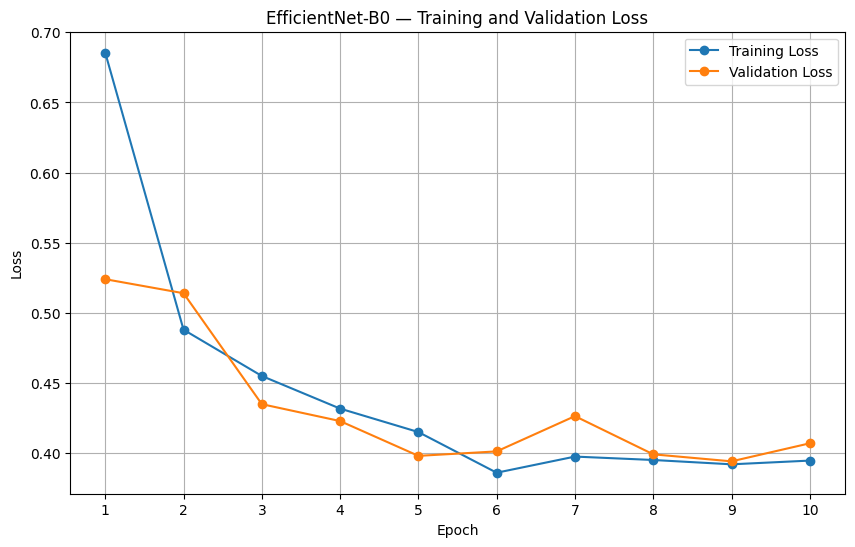

Loss curve saved to: /content/drive/MyDrive/MediScan/figures/day7_loss_curve.png


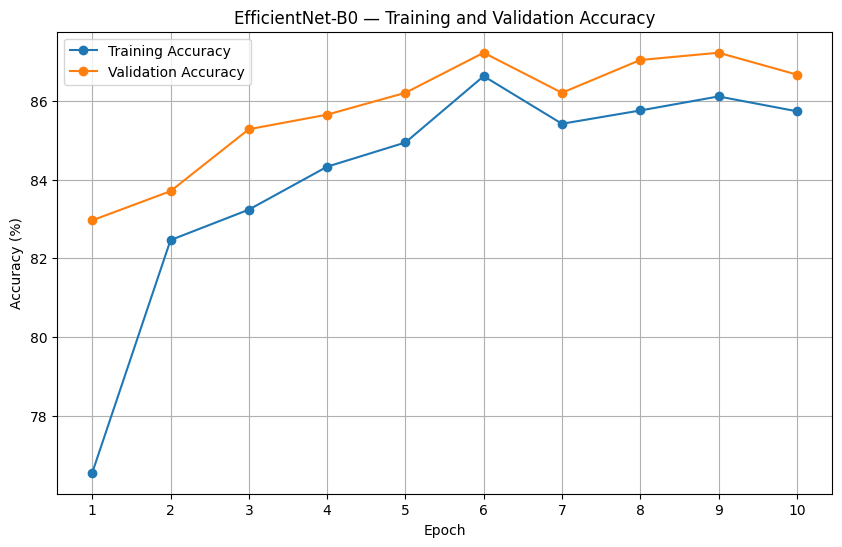

Accuracy curve saved to: /content/drive/MyDrive/MediScan/figures/day7_accuracy_curve.png
DAY 7 TRAINING CURVES SAVED


In [14]:
# ==================================================
# DAY 7 — TRAINING CURVES
# ==================================================

import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

# ==================================================
# LOSS CURVE
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 — Training and Validation Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)

loss_path = FIGURES_DIR / "day7_loss_curve.png"
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Loss curve saved to: {loss_path}")


# ==================================================
# ACCURACY CURVE
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    [x * 100 for x in history["train_accuracy"]],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in history["val_accuracy"]],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EfficientNet-B0 — Training and Validation Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)

accuracy_path = FIGURES_DIR / "day7_accuracy_curve.png"
plt.savefig(accuracy_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Accuracy curve saved to: {accuracy_path}")

print("=" * 50)
print("DAY 7 TRAINING CURVES SAVED")
print("=" * 50)

In [15]:
# ==================================================
# DAY 7 — SAVE TRAINING HISTORY & SUMMARY
# ==================================================

import json
import pandas as pd

# --------------------------------------------------
# Save training history as CSV
# --------------------------------------------------

history_df = pd.DataFrame({
    "epoch": list(range(1, NUM_EPOCHS + 1)),
    "train_loss": history["train_loss"],
    "train_accuracy": history["train_accuracy"],
    "val_loss": history["val_loss"],
    "val_accuracy": history["val_accuracy"],
    "learning_rate": history["learning_rate"]
})

history_path = REPORTS_DIR / "day7_training_history.csv"
history_df.to_csv(history_path, index=False)


# --------------------------------------------------
# Save history as JSON
# --------------------------------------------------

history_json_path = REPORTS_DIR / "day7_training_history.json"

with open(history_json_path, "w") as f:
    json.dump(history, f, indent=4)


# --------------------------------------------------
# Create Day 7 Summary
# --------------------------------------------------

best_epoch = history["val_accuracy"].index(best_val_accuracy) + 1

summary = f"""# Day 7 — Model Training

## Objective

Train the pretrained EfficientNet-B0 model and monitor training and validation performance.

## Training Configuration

- Architecture: EfficientNet-B0
- Pretrained: ImageNet
- Number of classes: 4
- Trainable parameters: 5,124
- Frozen parameters: 4,007,548
- Training samples: 5,040
- Validation samples: 1,080
- Batch size: 32
- Epochs: 10
- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Initial learning rate: 0.001
- Scheduler: StepLR
- Scheduler step size: 5
- Scheduler gamma: 0.1
- Device: CUDA

## Results

- Best validation accuracy: {best_val_accuracy * 100:.2f}%
- Best validation epoch: {best_epoch}
- Final training accuracy: {history["train_accuracy"][-1] * 100:.2f}%
- Final validation accuracy: {history["val_accuracy"][-1] * 100:.2f}%
- Best validation loss: {min(history["val_loss"]):.4f}

## Observations

- Training loss decreased substantially during training.
- Validation loss generally decreased throughout training.
- Validation accuracy reached 87.22%.
- The project target of greater than 85% validation accuracy was achieved.
- Learning rate was reduced from 0.001 to 0.0001 after epoch 5.
- No test-set evaluation was performed during Day 7.

## Saved Artifacts

- Best model: `models/efficientnet_b0_best_day7.pth`
- Loss curve: `figures/day7_loss_curve.png`
- Accuracy curve: `figures/day7_accuracy_curve.png`
- Training history: `reports/day7_training_history.csv`
- Training history JSON: `reports/day7_training_history.json`

## Day 7 Status

**COMPLETED**
"""

summary_path = REPORTS_DIR / "day7_summary.md"

with open(summary_path, "w") as f:
    f.write(summary)


# --------------------------------------------------
# Verification
# --------------------------------------------------

print("=" * 60)
print("DAY 7 DOCUMENTATION SAVED")
print("=" * 60)

print(f"Training history CSV : {history_path}")
print(f"Training history JSON: {history_json_path}")
print(f"Summary report       : {summary_path}")
print(f"Best validation acc  : {best_val_accuracy * 100:.2f}%")
print(f"Best epoch           : {best_epoch}")

print("=" * 60)
print("DAY 7 COMPLETE")
print("=" * 60)

DAY 7 DOCUMENTATION SAVED
Training history CSV : /content/drive/MyDrive/MediScan/reports/day7_training_history.csv
Training history JSON: /content/drive/MyDrive/MediScan/reports/day7_training_history.json
Summary report       : /content/drive/MyDrive/MediScan/reports/day7_summary.md
Best validation acc  : 87.22%
Best epoch           : 6
DAY 7 COMPLETE
